# Inverse Design Plugin

This notebook introduces the Inverse Design (`invdes`) plugin of Tidy3D.

The goal of `invdes` is to provide a simpler interface for setting up most practical inverse design problems. It wraps the lower-level `adjoint` plugin of Tidy3D to perform the gradient calculations, but allows the user to focus on the important aspects of their design without getting into the details of `jax`.

In this notebook, we'll give a simple demo showing the inverse design of a 1 -> 3 splitter using the inverse design plugin.

In [1]:
import matplotlib.pylab as plt
import numpy as np

import tidy3d as td
import tidy3d.plugins.invdes as tdi

## Setting Up the Inverse Design problem

The `invdes` problem works by constructing an `InverseDesign` object that contains all of the information about the problem we wish to optimize. This includes some base information about the simulation itself, information about the design region, and which monitors our objective will depend on.

In the next few cells we will define all of the compoennts we need to make an `InverseDesign`, but to start we will define some global parameters as usual.

In [2]:
# source info
wavelength = 1.0

# waveguide parameters
num_output_waveguides = 3
ly_wg = 0.5 * wavelength
buffer_wg = 1.0 * wavelength

# buffer between design region, pml, and sources
buffer = 1 * wavelength

# relative permittivity of material
eps_mat = 4.0

# resolution
min_steps_per_wvl = 20
pixel_size = wavelength / min_steps_per_wvl / np.sqrt(eps_mat)

Next we define some quantities derived from these parameters.

In [3]:
# spectral information
freq0 = td.C_0 / wavelength
fwidth = freq0 / 10
run_time = 50 / fwidth

# design region size in y
ly_des = num_output_waveguides * (ly_wg + buffer_wg)
lx_des = ly_des

# simulation size
Lx = 2 * buffer + lx_des + 2 * buffer
Ly = buffer + ly_des + buffer

# source and monitor locations
x_src = -lx_des/2 - buffer
x_mnt = -x_src

# material Medium
medium = td.Medium(permittivity=eps_mat)

# grid spec
grid_spec = td.GridSpec.auto(wavelength=wavelength, min_steps_per_wvl=min_steps_per_wvl)

# monitor names
def output_monitor_name(i: int) -> str:
    return f"MNT_{i}"

field_mnt_name = "field"

# mode spec
mode_spec = td.ModeSpec(num_modes=2)

### Define Base Simulation

Next we want to define the base `Simulation` that contains the static portions of our inverse design problem.

For this, we will make a bunch of regular `tidy3d` components (excluding the design region) and put them into a `td.Simulation`.


In [4]:
waveguide_in = td.Structure(
    geometry=td.Box(
        size=(Lx, ly_wg, td.inf),
        center=(-Lx + 2 * buffer, 0, 0),
    ),
    medium=medium,
)

In [5]:
y_max_wg_centers = (ly_des - buffer_wg) / 2 - buffer_wg/2
wg_y_centers_out = np.linspace(-y_max_wg_centers, y_max_wg_centers, num_output_waveguides)

waveguides_out = []
monitors_out = []
for i, wg_y_center in enumerate(wg_y_centers_out):

    wg_out = td.Structure(
        geometry=td.Box(
            size=(Lx, ly_wg, td.inf),
            center=(Lx - 2 * buffer, wg_y_center, 0),
        ),
        medium=medium,
    )

    waveguides_out.append(wg_out)

    mnt_out = td.ModeMonitor(
        size=(0, ly_wg + 2 * buffer, td.inf),
        center=(x_mnt, wg_y_center, 0),
        freqs=[freq0],
        name=output_monitor_name(i),
        mode_spec=mode_spec,
    )

    monitors_out.append(mnt_out)

In [6]:
source = td.ModeSource(
    size=(0, ly_wg + 2 * buffer, td.inf),
    center=(x_src, 0, 0),
    source_time=td.GaussianPulse(freq0=freq0, fwidth=fwidth),
    mode_index=0,
    direction="+",
)

fld_mnt = td.FieldMonitor(
    center=(0,0,0),
    size=(td.inf, td.inf, 0),
    freqs=[freq0],
    name=field_mnt_name,
)

In [7]:
simulation = td.Simulation(
    size=(Lx, Ly, 0),
    grid_spec=grid_spec,
    boundary_spec=td.BoundarySpec.pml(x=True, y=True, z=False),
    run_time=run_time,
    structures=[waveguide_in] + waveguides_out,
    sources=[source],
    monitors=[fld_mnt] + monitors_out,
)

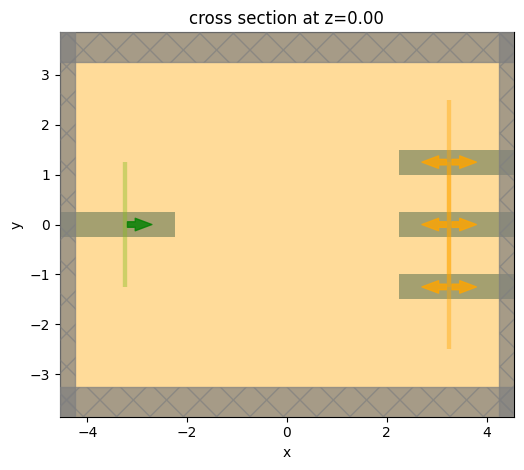

In [8]:
ax = simulation.plot(z=0)

### Define the Design Region

Next, we will introduce the `DesignRegion` component of the `invdes` plugin. This component contains specs that describe the design region structure and how it is rendered as a function of the optimization design parameters.

For now, we only support topology optimization design structures (pixellated grids) but in future versions we will support shape and level set design regions.

The `DesignRegion` combines geometric information about the design region with some information describing the pixellated grid. Furthermore, it also accepts a list of transformations and penalties, which respectively determine how the permittivity is rendered and how the optimization will penalize various expressions of the design region.

In [9]:
# transformations on the parameters that lead to the material density array (0,1)
filter_project = tdi.FilterProject(radius=0.1, beta=8.0)

# penalties applied to the state of the material density, after these transformations are applied
penalty = tdi.ErosionDilationPenalty(weight=0.3, length_scale=0.08)

design_region = tdi.TopologyDesignRegion(
        size=(lx_des, ly_des, td.inf),
        center=(0, 0, 0),
        eps_bounds=(1.0, eps_mat),
        transformations=[filter_project, filter_project],
        penalties=[penalty],
        pixel_size=pixel_size,
    )

Given an array of parameter values, this `design_region` object can be exported to a `JaxStructureStaticGeometry` from the `adjoint` plugin.

In [10]:
# generate initial parameters with a convenience function
params0 = design_region.params_random
params0 += np.fliplr(params0)
params0 /= 2
print(params0.shape)

(180, 180, 1)


In [11]:
jax_structure = design_region.to_jax_structure(params0)

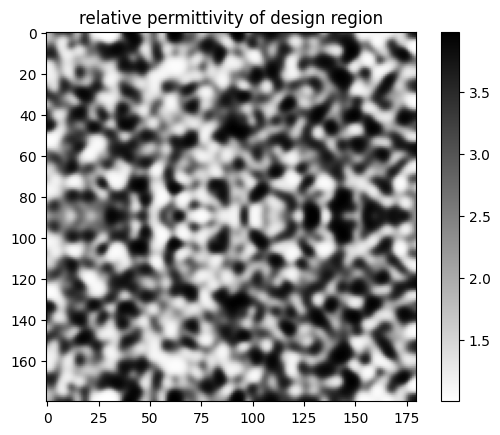

In [12]:
eps_xx_arr = jax_structure.medium.eps_dataset.eps_yy.values
im = plt.imshow(eps_xx_arr.squeeze().T, cmap="binary")
plt.colorbar(im)
plt.title('relative permittivity of design region')
plt.show()

#### Post-Process Function

We will define a post-processing function that takes a `tda.JaxSimulationData` and returns a `float`. 

> Note the return value will be **maximized** by our objective, minus any penalty values from the `DesignRegion`.

In our example, we can grab the output monitor modes, square them, and sum the results.

In [13]:
import jax.numpy as jnp
import tidy3d.plugins.adjoint as tda
import jax

# def post_process_fn(sim_data: tda.JaxSimulationData, step_index:int, history: dict) -> float:
#     """Function called internally to compute contribution to the objective function from the data."""
#     powers = [jnp.sum(abs(jnp.array(sim_data[mnt.name].amps.values))**2) for mnt in monitors_out]
#     powers = jnp.array(powers)
#     diff = jnp.abs(powers - 1.0/num_output_waveguides)**2
#     return -jnp.sum(diff)

def post_process_fn(sim_data: tda.JaxSimulationData, step_index:int, history: dict) -> float:
    """Function called internally to compute contribution to the objective function from the data."""
    powers = [jnp.sum(abs(jnp.array(sim_data[mnt.name].amps.values))**2) for mnt in monitors_out]
    powers = jnp.array(powers)
    softmin_weights = jax.nn.softmax(-powers)
    return jnp.sum(jnp.array(powers) * softmin_weights)

> Note: the extra `**kwargs` contain information passed during optimization about the history and the index of the step. They can be used to schedule changes into the post processing function as desired.

### Define the Inverse Design object

Next, we put the design region and simulation into an `InverseDesign`, which will capture everything we need to define the setup of our design problem.



In [14]:
design = tdi.InverseDesign(
    simulation=simulation,
    design_region=design_region,
    post_process_fn=post_process_fn,
    task_name="invdes",
    output_monitor_names=[mnt.name for mnt in monitors_out],
)

The `InverseDesign` object can be exported to a `JaxSimulation` from the `adjoint` plugin.

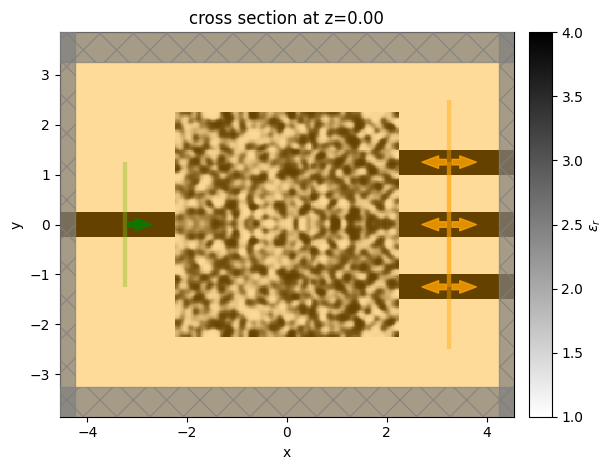

In [15]:
sim = design.to_simulation(params=params0)
ax = sim.plot_eps(z=0)

In [16]:
sim_data = design.to_simulation_data(params=params0, task_name="inspect")

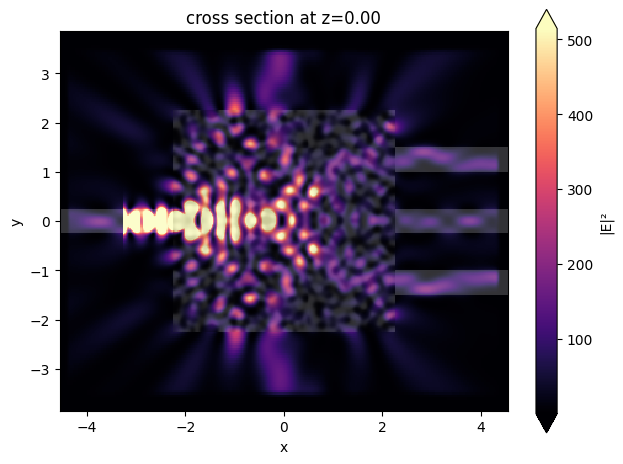

In [17]:
ax = sim_data.plot_field(field_mnt_name, field_name="E", val="abs^2")

## Optimization

Now that we've constructed our `InverseDesign` object, we can optimize it. We will need an `Optimizer` object, which contains all of the parameters of the optimization algorithm, and will provide a few methods to perform the optimization.

### Optimizer

Next, we define the optimizer, which stores our initial parameters, the gradient descent hyper-parameters, as well as a file path to save the history to.



In [18]:
optimizer = tdi.AdamOptimizer(
    design=design,
    history_save_fname="data/invdes_history.pkl",
    learning_rate=0.3,
    num_steps=10,
)

### Running the optimization

Finally, we can use `Optimizer.run(params0)` on our initial parameters to run the inverse design problem.

This will construct the objective funciton behind the scenes, use `jax` to differentiate it, and feed it to a gradient-descent optimizer from the `optax` package.


In [19]:
result = optimizer.run(params0)

step (1/10)
	objective_fn_val = -2.222e-01
	grad_norm = 2.234e-01
	post_process_val = 7.669e-02
	penalty = 2.989e-01
step (2/10)
	objective_fn_val = -9.460e-02
	grad_norm = 9.459e-03
	post_process_val = 5.266e-03
	penalty = 9.987e-02
step (3/10)
	objective_fn_val = -3.333e-02
	grad_norm = 2.730e-02
	post_process_val = 5.307e-02
	penalty = 8.640e-02
step (4/10)
	objective_fn_val = -5.502e-02
	grad_norm = 1.157e-02
	post_process_val = 2.630e-02
	penalty = 8.132e-02
step (5/10)
	objective_fn_val = -3.195e-02
	grad_norm = 1.118e-02
	post_process_val = 4.607e-02
	penalty = 7.802e-02
step (6/10)
	objective_fn_val = 8.924e-03
	grad_norm = 1.116e-02
	post_process_val = 8.442e-02
	penalty = 7.549e-02
step (7/10)
	objective_fn_val = 4.837e-02
	grad_norm = 9.993e-03
	post_process_val = 1.222e-01
	penalty = 7.379e-02
step (8/10)
	objective_fn_val = 8.081e-02
	grad_norm = 9.900e-03
	post_process_val = 1.533e-01
	penalty = 7.252e-02
step (9/10)
	objective_fn_val = 1.130e-01
	grad_norm = 8.283e-03
	p

## Optimization Results

The result of an optimization run will be stored as an `InverseDesignResult` object. This object has various fields storing information about the history of the optimization run, as well as a copy of the initial `InverseDesign` object.

### Loading an optimization run from backup file
If your optimization run was interrupted before you could get the `result` object. You can load if from the `optimizer.history_save_fname` if set. This file gets saved at every iteration with the most up to date `InverseDesignResult`.

In [20]:
result = tdi.InverseDesignResult.from_file(optimizer.history_save_fname)

### Continuing an optimization run

To continue an optimization run from where it left off, you can use `Optimizer.continue_run(results)`, passing in the `InverseDesignResult` object instead of an `InverseDesign`. The `InverseDesignResult` stores the state of the `optax` optimizer and therefore can continue without losing any information. The return value of this method will be an `InverseDesignResult` with the combined data.

In [21]:
# change some optimization parameters, if desired, set new number of steps
optimizer = optimizer.updated_copy(num_steps=2, learning_rate=0.1)

# continue the run, passing in the latest result
result = optimizer.continue_run(result=result)

step (1/2)
	objective_fn_val = 1.339e-01
	grad_norm = 8.458e-03
	post_process_val = 2.039e-01
	penalty = 6.997e-02
step (2/2)
	objective_fn_val = 1.401e-01
	grad_norm = 8.140e-03
	post_process_val = 2.097e-01
	penalty = 6.960e-02


### Analyzing and Exporting Results

The `InverseDesignResult` itself has many methods for analyzing results and exporting to various formats.

#### Quick plotting history

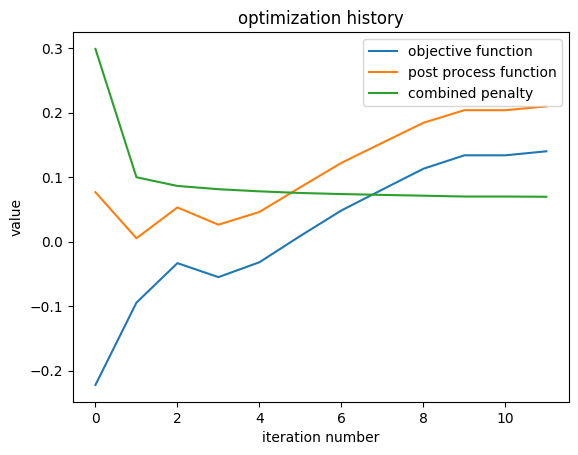

In [22]:
result.plot_optimization()
_ = plt.gca().set_title('optimization history')

#### Grabbing history data

`InverseDesignResult` objects have a `history` dictionary that stores the various parameters over the course of the optimization.

They also have some methods to conveniently grab data from that history.

In [23]:
history_keys = result.keys
history_penalty = result.history.get('penalty')
final_objective = result.get_final("objective_fn_val")

print(f"result contains '.history' for: {tuple(history_keys)}")
print(f"penalty history: {history_penalty}")
print(f"final objective function value: {final_objective}")

result contains '.history' for: ('params', 'objective_fn_val', 'grad', 'penalty', 'post_process_val', 'simulation', 'opt_state')
penalty history: [0.2988806664943695, 0.09986653178930283, 0.08639593422412872, 0.08131924271583557, 0.07802294939756393, 0.07549130916595459, 0.07379484921693802, 0.07251505553722382, 0.07126906514167786, 0.06997350603342056, 0.06997350603342056, 0.06960060447454453]
final objective function value: 0.14011836051940918


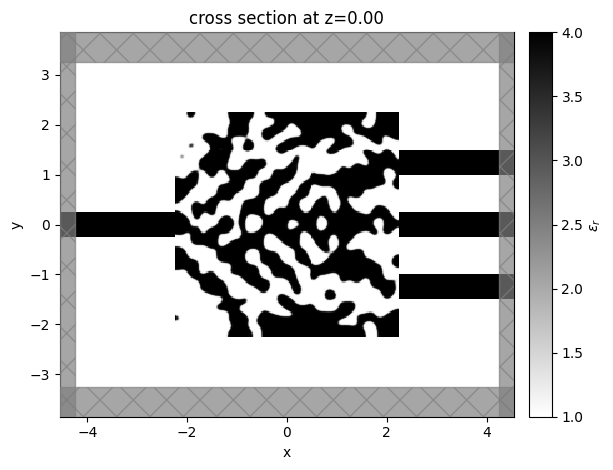

In [24]:
sim_final = result.sim_final
ax = sim_final.plot_eps(z=0, monitor_alpha=0.0, source_alpha=0.0)

↓ simulation_data.hdf5.gz ━━━━━━━━━━━━━ 100.0% • 4.3/4.3 MB • 6.5 MB/s • 0:00:00

17:39:33 JST loading simulation from simulation_data.hdf5

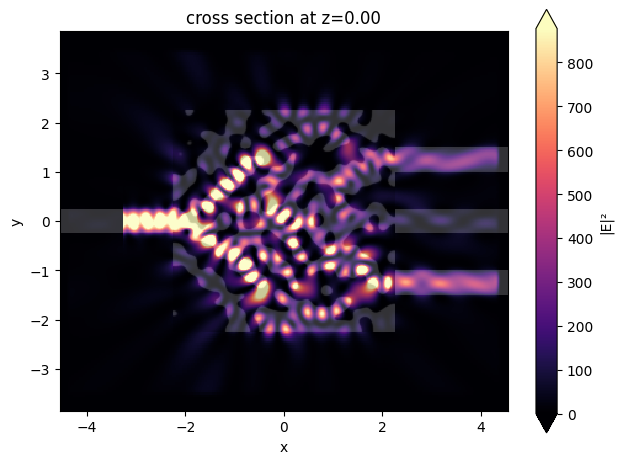

In [25]:
sim_data_final = result.sim_data_final(task_name="final_validation")
ax = sim_data_final.plot_field(field_mnt_name, field_name="E", val="abs^2")

#### Exporting to GDS

Use the regular GDS export functions from the `sim_final` to export to GDS.
```py
sim_final.to_gds(...)
```

## Notes
* What if the optimization requires several simulations? eg. 2 x 2 device with two different sources? maybe if `Design.simulation` is a list, we run each one in a `tda.run_async()` batch?
* kind of nicer to have the output monitors in the `simulation`.
DONE: `designregion.make_structure` -> `to_structure` (and others)
* What about a single design region `.resolution` parameter? that sets the pixel sizes and the param shape?
* `Design.to_simulation` and `to_simulation_data(task_name)`.
* Doesn't work if parameters are initially 1.0 (or 0.0?)